In [ ]:
import base64
import csv
import os
import random
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, ImageEnhance, ImageFilter


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_ROOT = Path.cwd()
DRIVE_ROOT = PROJECT_ROOT /"drive" /"MyDrive"/ "CV final project"
DATASET_ROOT = DRIVE_ROOT / "rwvc_bdd100k_balanced_300"
MANIFEST_PATH = DATASET_ROOT / "manifest.csv"
SYNTH_ROOT = DRIVE_ROOT / "synthesized"


print(f"Dataset root: {DATASET_ROOT}")
TRAIN_AUG_SPLIT = "train_aug"
AUG_IMAGES_PER_BUCKET = 20
RUN_SYNTHESIS = True
RUN_SYNTHESIS_BALANCE = True
SYNTH_IMAGES_PER_BUCKET = 20
SYNTH_MODEL = "gpt-image-1-mini"
SYNTH_SIZE = "1024x1024"
SYNTH_QUALITY = "low"
REQUEST_PAUSE_SECONDS = 1.0
TRAIN_SYNTH_SPLIT = "train_synth"
SYNTH_MANIFEST_PATH = SYNTH_ROOT / "manifest.csv"
TRAIN_AUG_REPORT_SPLIT = "train+aug"
TRAIN_SYNTH_REPORT_SPLIT = "train+synth"
COMBINED_TRAIN_SPLIT = "train+aug+synth"
SPLIT_DISPLAY_ORDER = ["train", "train+aug", "train+synth", "train+aug+synth", "valid", "test"]
AUGMENTATION_POLICY = "crop_flip_rotate_color_jitter_light_blur"






Dataset root: /content/drive/MyDrive/CV final project/rwvc_bdd100k_balanced_300


In [ ]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATASET_ROOT}")
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Manifest not found: {MANIFEST_PATH}")

manifest = pd.read_csv(MANIFEST_PATH)
required_columns = {"split", "output_path", "road", "visibility"}
missing_columns = required_columns - set(manifest.columns)
if missing_columns:
    raise ValueError(f"Manifest is missing required columns: {sorted(missing_columns)}")

manifest = manifest.copy()
manifest["path"] = manifest["output_path"].map(lambda p: DATASET_ROOT / p)
manifest["exists"] = manifest["path"].map(Path.exists)

missing_files = manifest.loc[~manifest["exists"], ["split", "output_path"]]
if len(missing_files):
    generated_splits = {"train_synth", "train_aug", "train_synth_aug"}
    missing_generated = missing_files[missing_files["split"].isin(generated_splits)]
    missing_original = missing_files[~missing_files["split"].isin(generated_splits)]

    if len(missing_original):
        display(missing_original.head())
        raise FileNotFoundError(
            f"{len(missing_original)} original train/valid/test image paths are missing"
        )

    print(
        f"Found {len(missing_generated)} stale generated manifest rows. "
        "Removing generated split rows from manifest.csv before rebuilding."
    )
    manifest = manifest.loc[~manifest["split"].isin(generated_splits)].copy()
    manifest = manifest.drop(columns=["exists"])
    manifest.to_csv(MANIFEST_PATH, index=False)
else:
    manifest = manifest.drop(columns=["exists"])

ROAD_CLASSES = ["dry", "snow", "wet"]
VISIBILITY_CLASSES = ["good", "poor"]

unexpected_roads = sorted(set(manifest["road"]) - set(ROAD_CLASSES))
unexpected_visibility = sorted(set(manifest["visibility"]) - set(VISIBILITY_CLASSES))
if unexpected_roads or unexpected_visibility:
    raise ValueError(
        f"Unexpected labels found. road={unexpected_roads}, visibility={unexpected_visibility}"
    )

print("Rows:", len(manifest))
print("Road classes:", ROAD_CLASSES)
print("Visibility classes:", VISIBILITY_CLASSES)
display(pd.crosstab([manifest["split"], manifest["road"]], manifest["visibility"]))


Found 994 stale generated manifest rows. Removing generated split rows from manifest.csv before rebuilding.
Rows: 300
Road classes: ['dry', 'snow', 'wet']
Visibility classes: ['good', 'poor']


visibility  good  poor
split road            
test  dry      9     5
      snow     9     9
      wet      9     9
train dry     35    21
      snow    36    36
      wet     36    36
valid dry      9     5
      snow     9     9
      wet      9     9

In [ ]:
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")


PROMPT_VISIBILITY = {
    "good": "clear visibility with readable lane markings, visible horizon, and minimal haze",
    "poor": "poor visibility from fog, spray, snowfall, or heavy precipitation with reduced distance detail",
}

PROMPT_ROAD = {
    "dry": "dry asphalt road surface",
    "wet": "wet reflective road surface after rain, with realistic puddles and tire spray",
    "snow": "snow-covered or slushy road surface with realistic winter driving conditions",
}


def synth_prompt(road: str, visibility: str, index: int) -> str:
    return (
        "Photorealistic forward-facing driving scene from an onboard vehicle camera, "
        "BDD100K-style urban or highway road image, no dashboard text, no watermark, no captions. "
        f"The road condition must be: {PROMPT_ROAD[road]}. "
        f"The visibility condition must be: {PROMPT_VISIBILITY[visibility]}. "
        "Include realistic traffic context, lane geometry, lighting, and perspective. "
        f"Generate a distinct sample number {index} for supervised road-condition classification."
    )


def ensure_synth_manifest_header(path: Path):
    if path.exists():
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["path", "road", "visibility", "model", "prompt"])
        writer.writeheader()


def append_synth_manifest(path: Path, row: dict):
    with path.open("a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["path", "road", "visibility", "model", "prompt"])
        writer.writerow(row)


def synthesize_bucket(client, road: str, visibility: str, target_count: int = SYNTH_IMAGES_PER_BUCKET):
    bucket_dir = SYNTH_ROOT / f"road={road}" / f"visibility={visibility}"
    bucket_dir.mkdir(parents=True, exist_ok=True)

    existing_paths = {
        bucket_dir / f"{SYNTH_MODEL}_{road}_{visibility}_{index:03d}.png"
        for index in range(target_count)
    }
    existing_count = sum(path.exists() for path in existing_paths)
    if existing_count >= target_count:
        print(f"Skipping {road}/{visibility}: already have {existing_count} images")
        return

    manifest_path = SYNTH_ROOT / "manifest.csv"
    ensure_synth_manifest_header(manifest_path)

    for index in range(target_count):
        prompt = synth_prompt(road, visibility, index)
        output_path = bucket_dir / f"{SYNTH_MODEL}_{road}_{visibility}_{index:03d}.png"
        if output_path.exists():
            continue

        response = client.images.generate(
            model=SYNTH_MODEL,
            prompt=prompt,
            size=SYNTH_SIZE,
            quality=SYNTH_QUALITY,
            n=1,
        )
        image_base64 = response.data[0].b64_json
        output_path.write_bytes(base64.b64decode(image_base64))

        append_synth_manifest(
            manifest_path,
            {
                "path": str(output_path.relative_to(PROJECT_ROOT)),
                "road": road,
                "visibility": visibility,
                "model": SYNTH_MODEL,
                "prompt": prompt,
            },
        )
        print(f"Saved {output_path}")
        time.sleep(REQUEST_PAUSE_SECONDS)


def current_synth_counts(synth_manifest_path: Path = SYNTH_ROOT / "manifest.csv"):
    if not synth_manifest_path.exists():
        return pd.Series(dtype="int64")
    synth_frame = pd.read_csv(synth_manifest_path)
    if synth_frame.empty:
        return pd.Series(dtype="int64")
    return synth_frame.groupby(["road", "visibility"]).size()


def synthesize_underrepresented_for_balanced_train_synth(client, base_synth_per_bucket: int = SYNTH_IMAGES_PER_BUCKET):
    """Generate base_synth_per_bucket for every bucket, then balance train+synth.

    Example: if base_synth_per_bucket is 20, the planner first treats every
    bucket as needing at least 20 synthesized images. It then adds extra
    synthesized images only for buckets whose train+synth total is still below
    the largest train+synth bucket.
    """
    train_counts = manifest.loc[manifest["split"] == "train"].groupby(["road", "visibility"]).size()
    synth_counts = current_synth_counts()

    baseline_combined_counts = {}
    for road in ROAD_CLASSES:
        for visibility in VISIBILITY_CLASSES:
            key = (road, visibility)
            train_count = int(train_counts.get(key, 0))
            existing_synth = int(synth_counts.get(key, 0))
            baseline_synth = max(existing_synth, base_synth_per_bucket)
            baseline_combined_counts[key] = train_count + baseline_synth

    target_train_plus_synth = max(baseline_combined_counts.values())

    plan_rows = []
    for road in ROAD_CLASSES:
        for visibility in VISIBILITY_CLASSES:
            key = (road, visibility)
            train_count = int(train_counts.get(key, 0))
            synth_count = int(synth_counts.get(key, 0))
            required_synth_total = max(base_synth_per_bucket, target_train_plus_synth - train_count)
            images_to_generate = max(0, required_synth_total - synth_count)
            plan_rows.append(
                {
                    "road": road,
                    "visibility": visibility,
                    "train": train_count,
                    "synth_existing": synth_count,
                    "base_synth": base_synth_per_bucket,
                    "required_synth_total": required_synth_total,
                    "train_plus_synth_after": train_count + required_synth_total,
                    "target_train_plus_synth": target_train_plus_synth,
                    "api_images_to_generate": images_to_generate,
                }
            )

    plan = pd.DataFrame(plan_rows)
    display(plan)

    for row in plan_rows:
        if row["api_images_to_generate"] <= 0:
            continue
        print(
            f"Generating {row['api_images_to_generate']} images for "
            f"{row['road']}/{row['visibility']} so train+synth reaches {target_train_plus_synth}"
        )
        synthesize_bucket(
            client,
            road=row["road"],
            visibility=row["visibility"],
            target_count=row["required_synth_total"],
        )

    return plan

if RUN_SYNTHESIS:
    if not os.getenv("OPENAI_API_KEY"):
        raise EnvironmentError("Set OPENAI_API_KEY before running synthesis")
    from openai import OpenAI

    client = OpenAI()
    if RUN_SYNTHESIS_BALANCE:
        synthesize_underrepresented_for_balanced_train_synth(client)
    else:
        for road in ROAD_CLASSES:
            for visibility in VISIBILITY_CLASSES:
                synthesize_bucket(client, road, visibility)
else:
    print("Synthesis skipped. Set RUN_SYNTHESIS = True to create images.")





,road,visibility,train,synth_existing,base_synth,required_synth_total,train_plus_synth_after,target_train_plus_synth,api_images_to_generate
0,dry,good,35,21,20,21,56,56,0
1,dry,poor,21,35,20,35,56,56,0
2,snow,good,36,20,20,20,56,56,0
3,snow,poor,36,20,20,20,56,56,0
4,wet,good,36,20,20,20,56,56,0
5,wet,poor,36,20,20,20,56,56,0


In [ ]:
def build_train_synth_split(
    dataset_root: Path = DATASET_ROOT,
    synth_manifest_path: Path = SYNTH_MANIFEST_PATH,
    overwrite: bool = False,
):
    """Create/update train_synth as synthesized images only."""
    dataset_root = Path(dataset_root)
    synth_manifest_path = Path(synth_manifest_path)
    manifest_path = dataset_root / "manifest.csv"
    train_synth_root = dataset_root / TRAIN_SYNTH_SPLIT

    if not dataset_root.exists():
        raise FileNotFoundError(f"Dataset not found: {dataset_root}")
    if not manifest_path.exists():
        raise FileNotFoundError(f"Manifest not found: {manifest_path}")
    if not synth_manifest_path.exists():
        raise FileNotFoundError(f"Synthesized manifest not found: {synth_manifest_path}")
    if train_synth_root.exists():
        if not overwrite:
            raise FileExistsError(
                f"Split folder already exists: {train_synth_root}. "
                "Pass overwrite=True to rebuild train_synth."
            )
        shutil.rmtree(train_synth_root)

    base_manifest = pd.read_csv(manifest_path).copy()
    original_manifest = base_manifest.loc[base_manifest["split"] != TRAIN_SYNTH_SPLIT].copy()

    synth_manifest = pd.read_csv(synth_manifest_path).copy()
    required_synth_columns = {"path", "road", "visibility", "model", "prompt"}
    missing_synth_columns = required_synth_columns - set(synth_manifest.columns)
    if missing_synth_columns:
        raise ValueError(f"Synthesized manifest missing columns: {sorted(missing_synth_columns)}")

    train_synth_rows = []
    for index, row in synth_manifest.reset_index(drop=True).iterrows():
        road = row["road"]
        visibility = row["visibility"]
        if road not in ROAD_CLASSES or visibility not in VISIBILITY_CLASSES:
            raise ValueError(f"Unexpected synthesized label at row {index}: {road=}, {visibility=}")

        source_image_path = PROJECT_ROOT / row["path"]
        if not source_image_path.exists():
            raise FileNotFoundError(f"Synthesized image is missing: {source_image_path}")

        filename = source_image_path.name
        relative_output_path = Path(TRAIN_SYNTH_SPLIT) / f"road={road}" / f"visibility={visibility}" / filename
        destination_image_path = dataset_root / relative_output_path
        destination_image_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source_image_path, destination_image_path)

        train_synth_rows.append(
            {
                "split": TRAIN_SYNTH_SPLIT,
                "source_split": "synthesized",
                "img": filename,
                "archive_member": "gpt-image-1-mini",
                "output_path": relative_output_path.as_posix(),
                "road": road,
                "visibility": visibility,
                "weather": "synthetic",
                "timeofday": "synthetic",
                "synth_model": row["model"],
                "synth_prompt": row["prompt"],
            }
        )

    train_synth_manifest = pd.DataFrame(train_synth_rows)
    updated_manifest = pd.concat([original_manifest, train_synth_manifest], ignore_index=True, sort=False)
    split_manifest_path = train_synth_root / "manifest.csv"
    train_synth_manifest.to_csv(split_manifest_path, index=False)
    updated_manifest.to_csv(manifest_path, index=False)

    missing_after_merge = updated_manifest.loc[
        ~updated_manifest["output_path"].map(lambda p: (dataset_root / p).exists()),
        "output_path",
    ]
    if len(missing_after_merge):
        raise FileNotFoundError(f"Updated manifest has {len(missing_after_merge)} missing image paths")

    loader_ready_manifest = updated_manifest.copy()
    loader_ready_manifest["path"] = loader_ready_manifest["output_path"].map(lambda p: dataset_root / p)

    print(f"Created split folder: {train_synth_root}")
    print(f"Saved split manifest: {split_manifest_path}")
    print(f"Updated master manifest: {manifest_path}")
    print(f"Synthesized images copied: {len(train_synth_manifest)}")
    print(f"Total manifest rows: {len(updated_manifest)}")
    return loader_ready_manifest


manifest = build_train_synth_split(overwrite=True)


Created split folder: /content/drive/MyDrive/CV final project/rwvc_bdd100k_balanced_300/train_synth
Saved split manifest: /content/drive/MyDrive/CV final project/rwvc_bdd100k_balanced_300/train_synth/manifest.csv
Updated master manifest: /content/drive/MyDrive/CV final project/rwvc_bdd100k_balanced_300/manifest.csv
Synthesized images copied: 136
Total manifest rows: 436


In [ ]:
def _random_resized_crop(image: Image.Image, min_scale: float = 0.85) -> Image.Image:
    width, height = image.size
    scale = random.uniform(min_scale, 1.0)
    crop_width = max(1, int(width * scale))
    crop_height = max(1, int(height * scale))
    left = random.randint(0, width - crop_width) if width > crop_width else 0
    top = random.randint(0, height - crop_height) if height > crop_height else 0
    image = image.crop((left, top, left + crop_width, top + crop_height))
    return image.resize((width, height), Image.Resampling.BILINEAR)


def augment_driving_image(image: Image.Image) -> Image.Image:
    """Apply mild, label-preserving augmentations for road-condition images."""
    image = image.convert("RGB")
    image = _random_resized_crop(image)

    if random.random() < 0.5:
        image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

    angle = random.uniform(-7.0, 7.0)
    image = image.rotate(angle, resample=Image.Resampling.BILINEAR, fillcolor=(0, 0, 0))

    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.80, 1.20))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.85, 1.20))
    image = ImageEnhance.Color(image).enhance(random.uniform(0.85, 1.15))

    if random.random() < 0.25:
        image = image.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 0.8)))

    return image


def build_train_aug_split(
    dataset_root: Path = DATASET_ROOT,
    base_aug_per_bucket: int = AUG_IMAGES_PER_BUCKET,
    overwrite: bool = False,
):
    """Create/update train_aug as augmented images only.

    The planner creates at least base_aug_per_bucket augmented images for
    every bucket, then adds extra augmented images only where needed so
    train + train_aug is balanced.
    """
    dataset_root = Path(dataset_root)
    manifest_path = dataset_root / "manifest.csv"
    train_aug_root = dataset_root / TRAIN_AUG_SPLIT

    if base_aug_per_bucket < 1:
        raise ValueError("base_aug_per_bucket must be at least 1")
    if not dataset_root.exists():
        raise FileNotFoundError(f"Dataset not found: {dataset_root}")
    if not manifest_path.exists():
        raise FileNotFoundError(f"Manifest not found: {manifest_path}")
    if train_aug_root.exists():
        if not overwrite:
            raise FileExistsError(
                f"Split folder already exists: {train_aug_root}. "
                "Pass overwrite=True to rebuild train_aug."
            )
        shutil.rmtree(train_aug_root)

    base_manifest = pd.read_csv(manifest_path).copy()
    original_manifest = base_manifest.loc[base_manifest["split"] != TRAIN_AUG_SPLIT].copy()
    train_manifest = original_manifest.loc[original_manifest["split"] == "train"].copy()
    if train_manifest.empty:
        raise ValueError("No original train rows found in manifest")

    bucket_sizes = train_manifest.groupby(["road", "visibility"]).size()
    target_train_plus_aug = int((bucket_sizes + base_aug_per_bucket).max())

    train_aug_rows = []
    for (road, visibility), bucket_frame in train_manifest.groupby(["road", "visibility"], sort=False):
        bucket_frame = bucket_frame.reset_index(drop=True)
        original_count = len(bucket_frame)
        augmentations_needed = max(base_aug_per_bucket, target_train_plus_aug - original_count)
        for aug_number in range(augmentations_needed):
            source_row = bucket_frame.iloc[aug_number % len(bucket_frame)]
            source_image_path = dataset_root / source_row["output_path"]
            with Image.open(source_image_path) as source_image:
                augmented_image = augment_driving_image(source_image)

            filename = f"aug_{aug_number:04d}_{source_image_path.stem}{source_image_path.suffix.lower()}"
            relative_output_path = Path(TRAIN_AUG_SPLIT) / f"road={road}" / f"visibility={visibility}" / filename
            destination_image_path = dataset_root / relative_output_path
            destination_image_path.parent.mkdir(parents=True, exist_ok=True)
            augmented_image.save(destination_image_path, quality=95)

            new_row = source_row.to_dict()
            new_row["split"] = TRAIN_AUG_SPLIT
            new_row["source_split"] = "train_augmented"
            new_row["img"] = filename
            new_row["archive_member"] = "local_augmentation"
            new_row["output_path"] = relative_output_path.as_posix()
            new_row["augmentation_policy"] = AUGMENTATION_POLICY
            train_aug_rows.append(new_row)

    train_aug_manifest = pd.DataFrame(train_aug_rows)
    updated_manifest = pd.concat([original_manifest, train_aug_manifest], ignore_index=True, sort=False)
    split_manifest_path = train_aug_root / "manifest.csv"
    train_aug_manifest.to_csv(split_manifest_path, index=False)
    updated_manifest.to_csv(manifest_path, index=False)

    missing_after_aug = updated_manifest.loc[
        ~updated_manifest["output_path"].map(lambda p: (dataset_root / p).exists()),
        "output_path",
    ]
    if len(missing_after_aug):
        raise FileNotFoundError(f"Updated manifest has {len(missing_after_aug)} missing image paths")

    train_aug_counts = bucket_count_table(train_aug_manifest) if "bucket_count_table" in globals() else None
    loader_ready_manifest = updated_manifest.copy()
    loader_ready_manifest["path"] = loader_ready_manifest["output_path"].map(lambda p: dataset_root / p)

    print(f"Created split folder: {train_aug_root}")
    print(f"Saved split manifest: {split_manifest_path}")
    print(f"Updated master manifest: {manifest_path}")
    print(f"Base augmented images per road/visibility bucket: {base_aug_per_bucket}")
    print(f"Target train+aug images per road/visibility bucket: {target_train_plus_aug}")
    print(f"train_aug rows: {len(train_aug_manifest)}")
    print(f"Total manifest rows: {len(updated_manifest)}")
    if train_aug_counts is not None:
        display(train_aug_counts)
    return loader_ready_manifest


manifest = build_train_aug_split(overwrite=True)




Created split folder: /content/drive/MyDrive/CV final project/rwvc_bdd100k_balanced_300/train_aug
Saved split manifest: /content/drive/MyDrive/CV final project/rwvc_bdd100k_balanced_300/train_aug/manifest.csv
Updated master manifest: /content/drive/MyDrive/CV final project/rwvc_bdd100k_balanced_300/manifest.csv
Base augmented images per road/visibility bucket: 20
Target train+aug images per road/visibility bucket: 56
train_aug rows: 136
Total manifest rows: 572


,split,road,visibility,images,bucket
0,train_aug,dry,good,21,dry / good
1,train_aug,dry,poor,35,dry / poor
2,train_aug,snow,good,20,snow / good
3,train_aug,snow,poor,20,snow / poor
4,train_aug,wet,good,20,wet / good
5,train_aug,wet,poor,20,wet / poor


Split sizes:


,split,images
0,train,200
1,train+aug,336
2,train+synth,336
3,train+aug+synth,456
4,valid,50
5,test,50


Road/visibility bucket counts:


,split,road,visibility,images,bucket
0,train,dry,good,35,dry / good
1,train,dry,poor,21,dry / poor
2,train,snow,good,36,snow / good
3,train,snow,poor,36,snow / poor
4,train,wet,good,36,wet / good
5,train,wet,poor,36,wet / poor
6,train+aug,dry,good,56,dry / good
7,train+aug,dry,poor,56,dry / poor
8,train+aug,snow,good,56,snow / good
9,train+aug,snow,poor,56,snow / poor


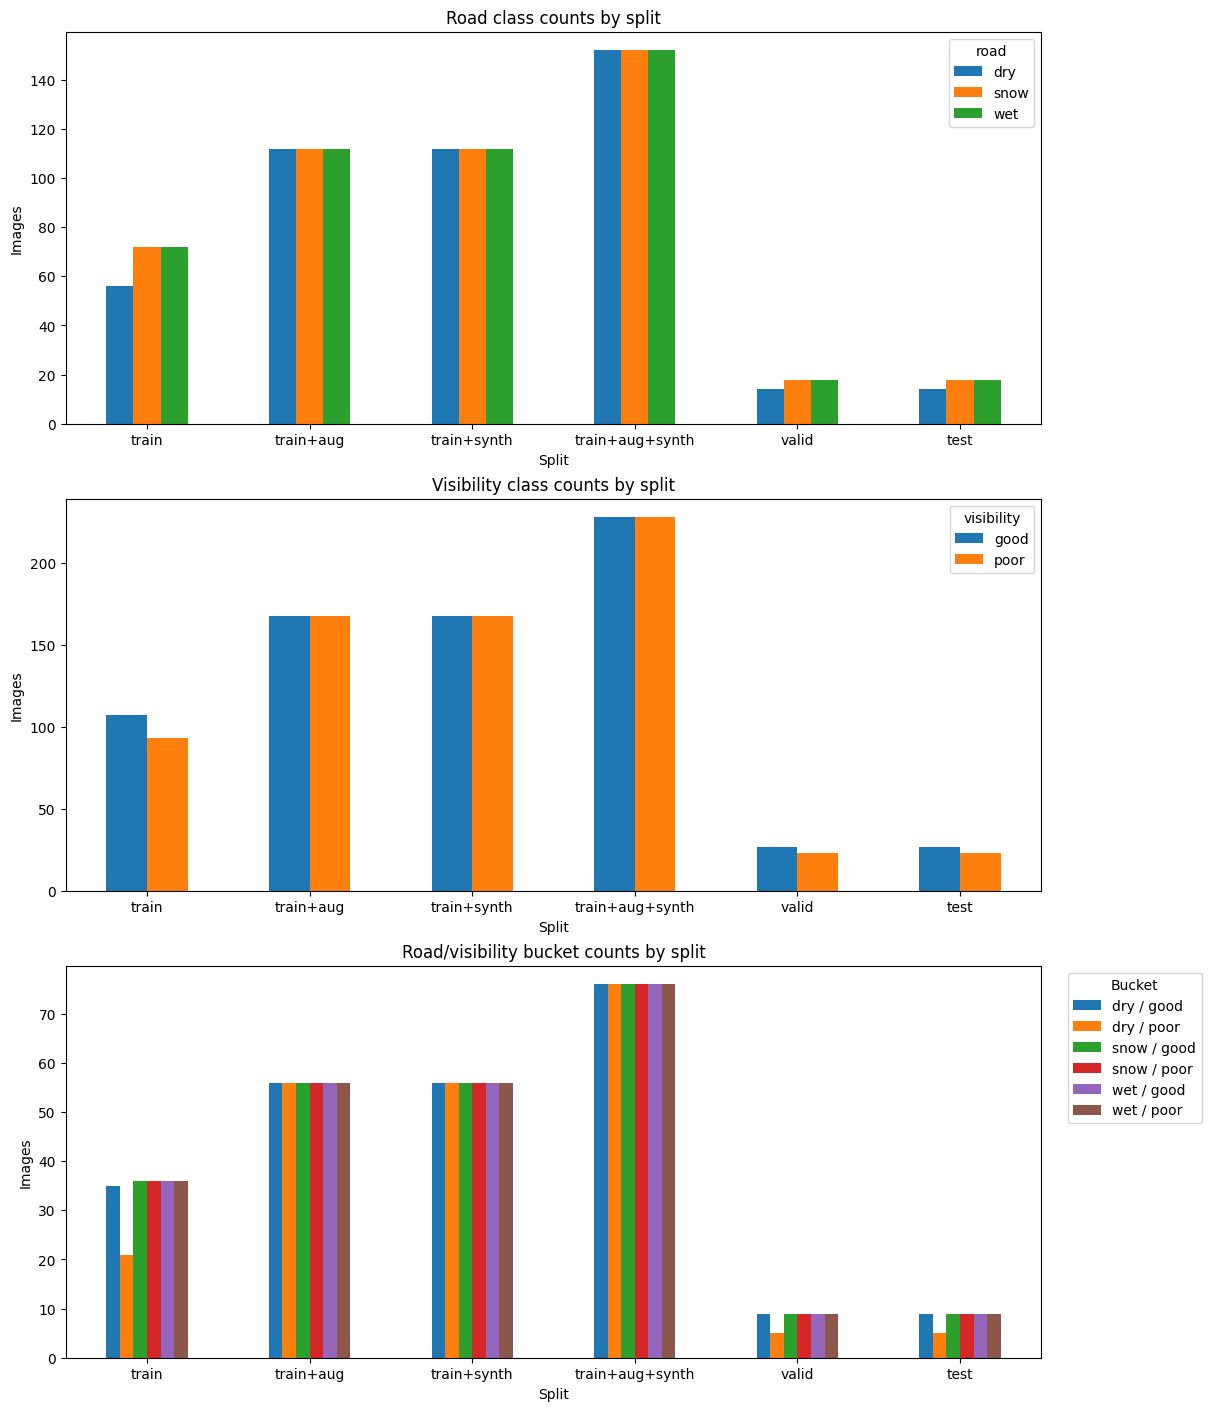

In [ ]:
def refresh_manifest(dataset_root: Path = DATASET_ROOT):
    """Reload manifest.csv and add the absolute path column expected by the Dataset."""
    dataset_root = Path(dataset_root)
    refreshed = pd.read_csv(dataset_root / "manifest.csv").copy()
    refreshed["path"] = refreshed["output_path"].map(lambda p: dataset_root / p)
    return refreshed


def balance_frame_by_bucket(frame: pd.DataFrame):
    """Downsample a frame so every road/visibility bucket has the same count."""
    if frame.empty:
        return frame.copy()

    bucket_counts = frame.groupby(["road", "visibility"]).size()
    target = int(bucket_counts.min())
    balanced_parts = []

    for (road, visibility), bucket_frame in frame.groupby(["road", "visibility"], sort=False):
        bucket_frame = bucket_frame.copy()
        if "source_split" in bucket_frame.columns:
            # Keep real/augmented rows before synthetic rows when downsampling extras.
            source_priority = {
                "train": 0,
                "train_augmented": 1,
                "synthesized": 2,
            }
            bucket_frame["_source_priority"] = bucket_frame["source_split"].map(source_priority).fillna(1)
            bucket_frame = bucket_frame.sort_values(["_source_priority", "output_path"]).drop(columns=["_source_priority"])
        else:
            bucket_frame = bucket_frame.sort_values("output_path")
        balanced_parts.append(bucket_frame.head(target))

    return pd.concat(balanced_parts, ignore_index=True, sort=False)


def add_reporting_training_views(frame: pd.DataFrame):
    """Add reporting-only splits that show the actual concatenated training corpuses."""
    base_display_splits = ["train", "valid", "test"]
    output = [frame.loc[frame["split"].isin(base_display_splits)].copy()]

    reporting_views = {
        TRAIN_AUG_REPORT_SPLIT: (["train", "train_aug"], False),
        TRAIN_SYNTH_REPORT_SPLIT: (["train", "train_synth"], False),
        COMBINED_TRAIN_SPLIT: (["train", "train_aug", "train_synth"], True),
    }

    available_splits = set(frame["split"])
    for report_split, (source_splits, balance) in reporting_views.items():
        available_source_splits = [split for split in source_splits if split in available_splits]
        combined = frame.loc[frame["split"].isin(available_source_splits)].copy()
        if combined.empty:
            continue
        if balance:
            combined = balance_frame_by_bucket(combined)
        combined["split"] = report_split
        output.append(combined)

    return pd.concat(output, ignore_index=True, sort=False)

def split_size_table(frame: pd.DataFrame):
    split_counts = frame.groupby("split").size().rename("images").reset_index()
    split_counts["split"] = pd.Categorical(
        split_counts["split"],
        categories=[split for split in SPLIT_DISPLAY_ORDER if split in set(split_counts["split"])],
        ordered=True,
    )
    return split_counts.sort_values("split").reset_index(drop=True)


def bucket_count_table(frame: pd.DataFrame):
    counts = (
        frame.groupby(["split", "road", "visibility"])
        .size()
        .rename("images")
        .reset_index()
    )
    counts["bucket"] = counts["road"] + " / " + counts["visibility"]
    counts["split"] = pd.Categorical(
        counts["split"],
        categories=[split for split in SPLIT_DISPLAY_ORDER if split in set(counts["split"])],
        ordered=True,
    )
    return counts.sort_values(["split", "road", "visibility"]).reset_index(drop=True)


def plot_class_counts(frame: pd.DataFrame, split_order: list[str] = SPLIT_DISPLAY_ORDER):
    available_splits = [split for split in split_order if split in set(frame["split"])]
    if not available_splits:
        raise ValueError("No known splits found in manifest")

    plot_frame = frame.loc[frame["split"].isin(available_splits)].copy()
    plot_frame["bucket"] = plot_frame["road"] + " / " + plot_frame["visibility"]

    fig, axes = plt.subplots(3, 1, figsize=(12, 14), constrained_layout=True)

    road_counts = pd.crosstab(plot_frame["split"], plot_frame["road"]).reindex(available_splits)
    road_counts.plot(kind="bar", ax=axes[0], rot=0)
    axes[0].set_title("Road class counts by split")
    axes[0].set_xlabel("Split")
    axes[0].set_ylabel("Images")

    visibility_counts = pd.crosstab(plot_frame["split"], plot_frame["visibility"]).reindex(available_splits)
    visibility_counts.plot(kind="bar", ax=axes[1], rot=0)
    axes[1].set_title("Visibility class counts by split")
    axes[1].set_xlabel("Split")
    axes[1].set_ylabel("Images")

    bucket_counts = pd.crosstab(plot_frame["split"], plot_frame["bucket"]).reindex(available_splits)
    bucket_counts.plot(kind="bar", ax=axes[2], rot=0)
    axes[2].set_title("Road/visibility bucket counts by split")
    axes[2].set_xlabel("Split")
    axes[2].set_ylabel("Images")
    axes[2].legend(title="Bucket", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.show()

    return {
        "road_counts": road_counts,
        "visibility_counts": visibility_counts,
        "bucket_counts": bucket_counts,
    }


manifest = refresh_manifest()
plot_manifest = add_reporting_training_views(manifest)

print("Split sizes:")
display(split_size_table(plot_manifest))

print("Road/visibility bucket counts:")
display(bucket_count_table(plot_manifest))

class_count_tables = plot_class_counts(plot_manifest)







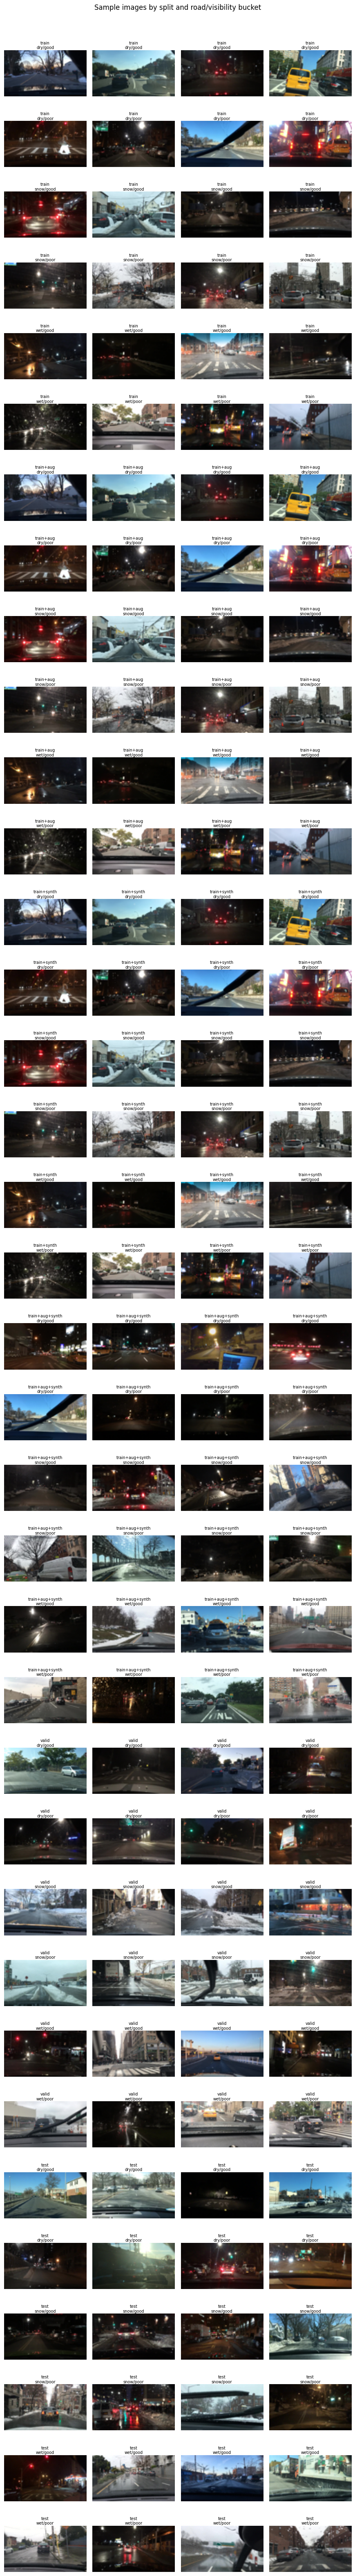

In [ ]:
def show_bucket_image_grid(
    frame: pd.DataFrame,
    dataset_root: Path = DATASET_ROOT,
    splits: list[str] | None = None,
    samples_per_bucket: int = 4,
    thumbnail_size: tuple[int, int] = (96, 54),
):
    """Show small image samples for each road/visibility bucket in each split."""
    dataset_root = Path(dataset_root)
    if splits is None:
        splits = [split for split in SPLIT_DISPLAY_ORDER if split in set(frame["split"])]

    buckets = [(road, visibility) for road in ROAD_CLASSES for visibility in VISIBILITY_CLASSES]
    rows = []
    for split in splits:
        for road, visibility in buckets:
            bucket_rows = frame.loc[
                (frame["split"] == split)
                & (frame["road"] == road)
                & (frame["visibility"] == visibility)
            ].head(samples_per_bucket)
            if len(bucket_rows):
                rows.append((split, road, visibility, bucket_rows))

    if not rows:
        raise ValueError("No images found for requested split/bucket grid")

    fig, axes = plt.subplots(
        nrows=len(rows),
        ncols=samples_per_bucket,
        figsize=(samples_per_bucket * 2.2, len(rows) * 1.75),
        squeeze=False,
    )

    for row_idx, (split, road, visibility, bucket_rows) in enumerate(rows):
        for col_idx in range(samples_per_bucket):
            ax = axes[row_idx][col_idx]
            ax.axis("off")

            if col_idx >= len(bucket_rows):
                continue

            item = bucket_rows.iloc[col_idx]
            image_path = dataset_root / item["output_path"]
            with Image.open(image_path) as image:
                image = image.convert("RGB")
                image.thumbnail(thumbnail_size)
                ax.imshow(image)

            ax.set_title(f"{split}\n{road}/{visibility}", fontsize=7, pad=2)

            if col_idx == 0:
                ax.set_ylabel(
                    f"{split}\n{road}/{visibility}",
                    rotation=0,
                    ha="right",
                    va="center",
                    fontsize=8,
                    labelpad=40,
                )

    fig.suptitle("Sample images by split and road/visibility bucket", y=1.005)
    plt.tight_layout()
    plt.show()


manifest = refresh_manifest()
plot_manifest = add_reporting_training_views(manifest)
show_bucket_image_grid(
    plot_manifest,
    splits=["train", "train+aug", "train+synth", "train+aug+synth", "valid", "test"],
    samples_per_bucket=4,
)





